In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helper import load_params_csv
from run import run_sim

In [13]:
params = load_params_csv('params/model_param.csv')
params

{'R_0': 464.392,
 'mu_0': 0.1188,
 'mu_hat': 0.0601,
 'kappa_mu': 0.2772,
 'sigma': 0.1819,
 'eta': 0.48,
 'theta': 0.6376,
 'gamma': 0.1009,
 'F_0': 11.3,
 'tau': 0.24,
 'r_bar': 0.04,
 'pi': 0.055,
 'rho12': 0.0}

In [15]:
T = 3
n_steps = T * 24
alpha = 0.6
entry_mult = 25
output = run_sim(
    params,
    n_steps=n_steps,
    n_paths=1_000,
    T = T,
    alpha=alpha,
    entry_mult=entry_mult,
    seed=99,
    stochastic_ir = False,
    return_all = True
)

In [17]:
output.keys()

dict_keys(['R', 'C', 'Y', 'mus', 'sigma', 'eta', 'dW', 'dt', 'D', 'I', 'P', 'defaulted', 'CF', 'r'])

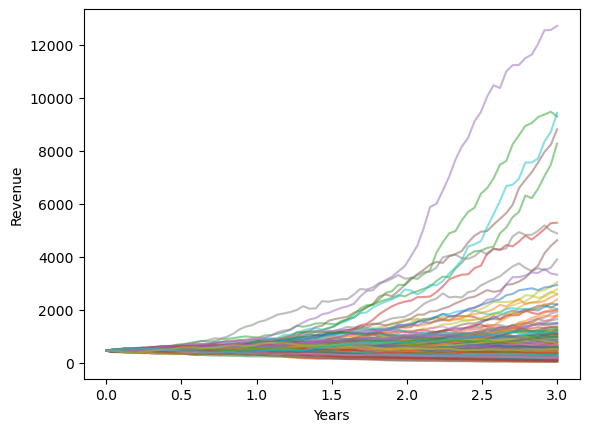

In [19]:
fig, ax = plt.subplots()

grid = np.linspace(0, T, n_steps)

for path in output['R'][:200]:
    ax.plot(grid, (path), alpha=.5)
ax.set_xlabel('Years')
ax.set_ylabel('Revenue')

plt.show()

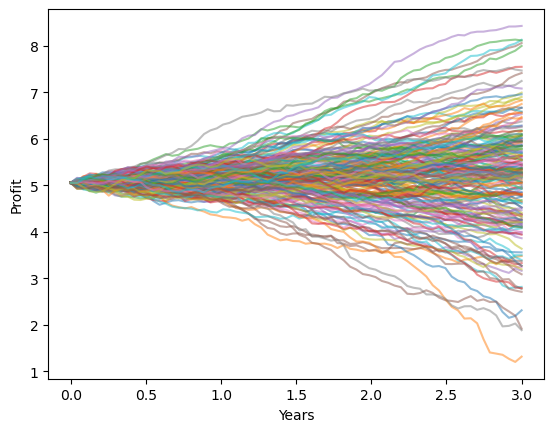

In [21]:
fig, ax = plt.subplots()

grid = np.linspace(0, T, n_steps)

for path in output['Y'][:200]:
    ax.plot(grid, np.log(path), alpha=.5)
ax.set_xlabel('Years')
ax.set_ylabel('Profit')

plt.show()

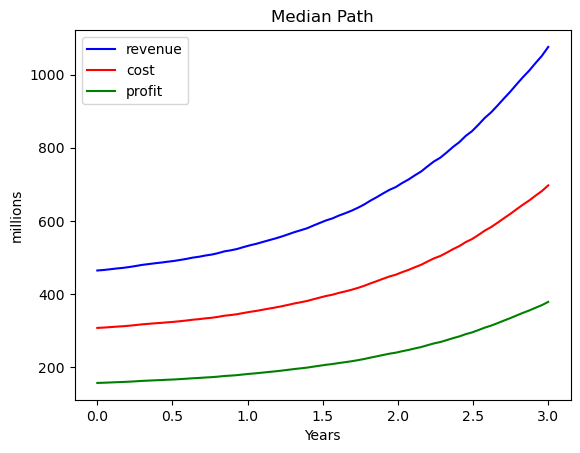

In [23]:
R_mean = output['R'].mean(axis=0)
C_mean = output['C'].mean(axis=0)
Y_mean = output['Y'].mean(axis=0)

fig, ax = plt.subplots()
ax.set_title('Median Path')
ax.plot(grid, R_mean, color='blue', label='revenue')
ax.plot(grid, C_mean, color='red', label='cost')
ax.plot(grid, Y_mean, color='green', label='profit')
ax.legend()
ax.set_xlabel('Years')
ax.set_ylabel('millions')
    
plt.show()

In [25]:
default_rate = output['defaulted'][:, -1].mean()
default_rate

0.006

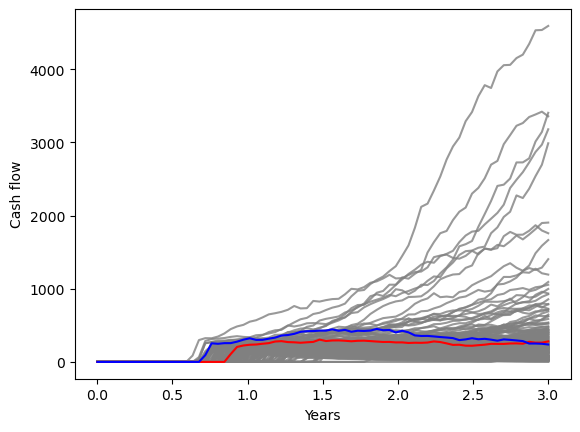

In [27]:
fig, ax = plt.subplots()
for path in output['CF'][:200]:
    ax.plot(grid, path, alpha=0.8, color='grey')
ax.plot(grid, output['CF'][133], alpha=1, color='red')
ax.plot(grid, output['CF'][166], alpha=1, color='blue')
ax.set_xlabel("Years")
ax.set_ylabel("Cash flow")
plt.show()

/var/folders/8z/6vyvm84j61z3zv4ynthd44m00000gn/T/ipykernel_71748/176235230.py:3: RuntimeWarning: divide by zero encountered in log
  ax.plot(np.log(path), alpha=0.5)


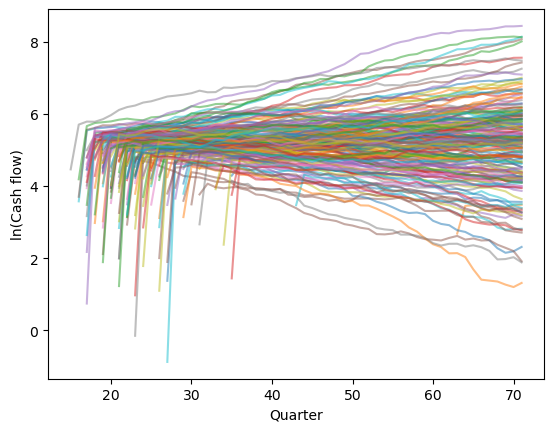

In [29]:
fig, ax = plt.subplots()
for path in output['CF'][:200]:
    ax.plot(np.log(path), alpha=0.5)
ax.set_xlabel("Quarter")
ax.set_ylabel("ln(Cash flow)")
plt.show()

TypeError: 'float' object is not subscriptable

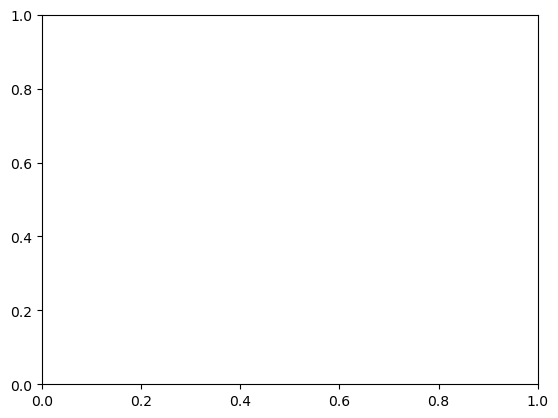

In [33]:
fig, ax = plt.subplots()
for path in output['r'][:200]:
    ax.plot(path, alpha=0.5)
ax.set_xlabel("Quarter")
ax.set_ylabel("Interest")
plt.show()